In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
dataset = pd.read_csv('Data/twitchdata-update.csv')
dataset


,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English
...,...,...,...,...,...,...,...,...,...,...,...
995,LITkillah,122524635,13560,21359,9104,601927,562691,2162107,True,False,Spanish
996,빅헤드 (bighead033),122523705,153000,3940,793,213212,52289,4399897,True,False,Korean
997,마스카 (newmasca),122452320,217410,6431,567,109068,-4942,3417970,True,False,Korean
998,AndyMilonakis,122311065,104745,10543,1153,547446,109111,3926918,True,False,English


In [17]:
print("Columns in dataset:")
print(dataset.columns)

Columns in dataset:
Index(['Channel', 'Watch time(Minutes)', 'Stream time(minutes)',
       'Peak viewers', 'Average viewers', 'Followers', 'Followers gained',
       'Views gained', 'Partnered', 'Mature', 'Language'],
      dtype='object')


In [15]:
def descriptive_statistics(sample, field):
    
    if field not in sample.columns:
        raise ValueError(f"Column '{field}' not found.")
    
    data = sample[field].dropna()
    
    stats_dict = {
        "count": data.count(),
        "mean": data.mean(),
        "median": data.median(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
        "Q1": data.quantile(0.25),
        "Q3": data.quantile(0.75)
    }
    
    # Visualization
    plt.figure(figsize=(8, 6))
    
    plt.subplot(2, 1, 1)
    plt.hist(data)
    plt.title(f'Histogram of {field}')
    
    plt.subplot(2, 1, 2)
    plt.boxplot(data, vert=False)
    plt.title(f'Boxplot of {field}')
    
    plt.tight_layout()
    
    stats_dict["visualization"] = plt
    
    return stats_dict


In [18]:
sample_dataset = dataset.sample(n=150, random_state=42)


In [21]:
sample_dataset.columns = sample_dataset.columns.str.strip()

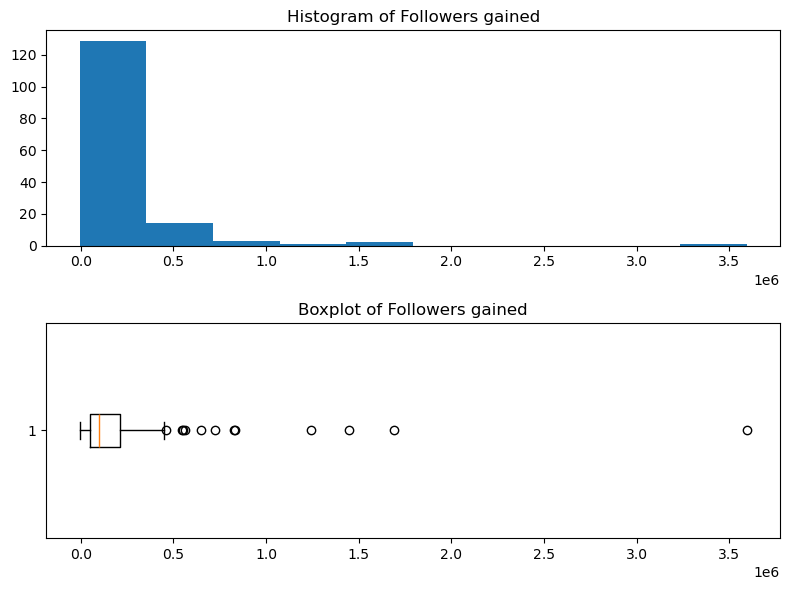

In [23]:
result = descriptive_statistics(sample_dataset, "Followers gained")


In [24]:
print("\nDescriptive Statistics:")
print(result)


Descriptive Statistics:
{'count': np.int64(150), 'mean': np.float64(204656.76), 'median': 100720.0, 'std': 371011.1848849221, 'min': -5405, 'max': 3593081, 'Q1': np.float64(48934.25), 'Q3': np.float64(211129.75), 'visualization': <module 'matplotlib.pyplot' from 'C:\\Users\\PC\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>}


In [26]:
result["visualization"].show()